In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
df = pd.read_csv("../data/raw/products.csv")

In [3]:
df.head()

,Product Name,Price,Rating,Availability,Product URL
0,A Light in the Attic,51.77,Three,In stock,catalogue/a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,53.74,One,In stock,catalogue/tipping-the-velvet_999/index.html
2,Soumission,50.10,One,In stock,catalogue/soumission_998/index.html
3,Sharp Objects,47.82,Four,In stock,catalogue/sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,catalogue/sapiens-a-brief-history-of-humankind...


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 5


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product Name  1000 non-null   str    
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   str    
 3   Availability  1000 non-null   str    
 4   Product URL   1000 non-null   str    
dtypes: float64(1), str(4)
memory usage: 39.2 KB


In [7]:
df.describe()

,Price
count,1000.00000
mean,35.07035
std,14.44669
min,10.00000
25%,22.10750
50%,35.98000
75%,47.45750
max,59.99000


In [8]:
df.isnull().sum()

Product Name    0
Price           0
Rating          0
Availability    0
Product URL     0
dtype: int64

In [12]:
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("£", "", regex=False)
    .astype(float)
)

df.head()

,Product Name,Price,Rating,Availability,Product URL
0,A Light in the Attic,51.77,Three,In stock,catalogue/a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,53.74,One,In stock,catalogue/tipping-the-velvet_999/index.html
2,Soumission,50.10,One,In stock,catalogue/soumission_998/index.html
3,Sharp Objects,47.82,Four,In stock,catalogue/sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,catalogue/sapiens-a-brief-history-of-humankind...


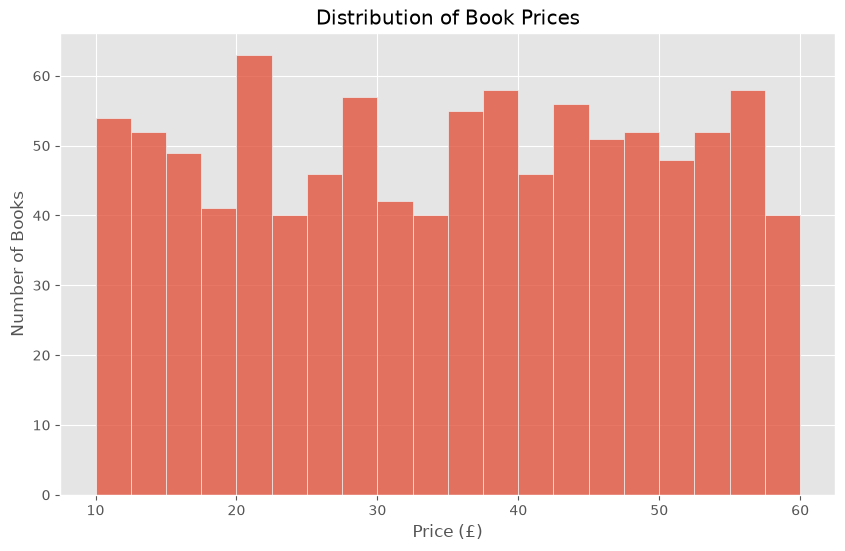

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(df["Price"], bins=20)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

In [14]:
print("Average Price:", round(df["Price"].mean(),2))


Average Price: 35.07


In [15]:
print("Cheapest Book")

display(df.loc[df["Price"].idxmin()])

print("\nMost Expensive Book")

display(df.loc[df["Price"].idxmax()])

Cheapest Book


Product Name                   An Abundance of Katherines
Price                                                10.0
Rating                                               Five
Availability                                     In stock
Product URL     an-abundance-of-katherines_362/index.html
Name: 638, dtype: object


Most Expensive Book


Product Name                The Perfect Play (Play by Play #1)
Price                                                    59.99
Rating                                                   Three
Availability                                          In stock
Product URL     the-perfect-play-play-by-play-1_352/index.html
Name: 648, dtype: object

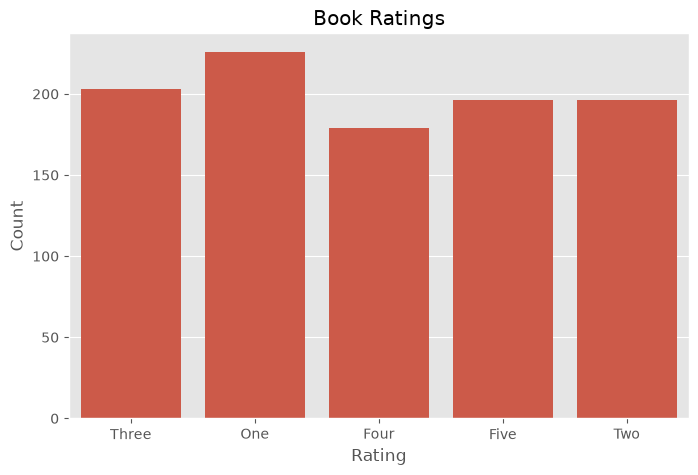

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Rating")

plt.title("Book Ratings")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

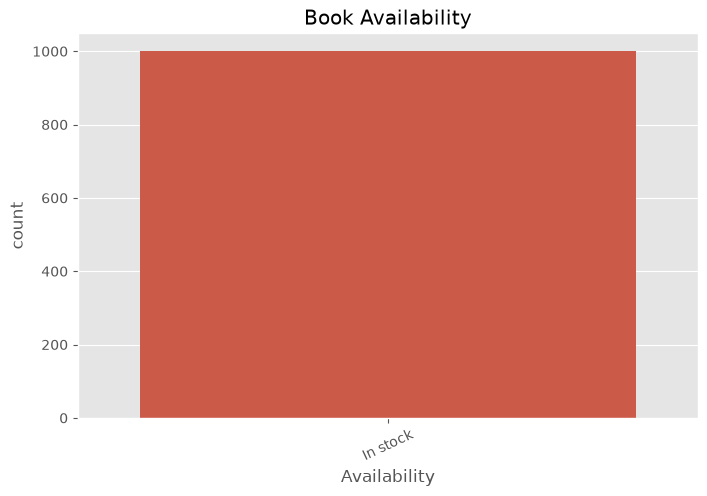

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Availability")

plt.xticks(rotation=25)

plt.title("Book Availability")

plt.show()

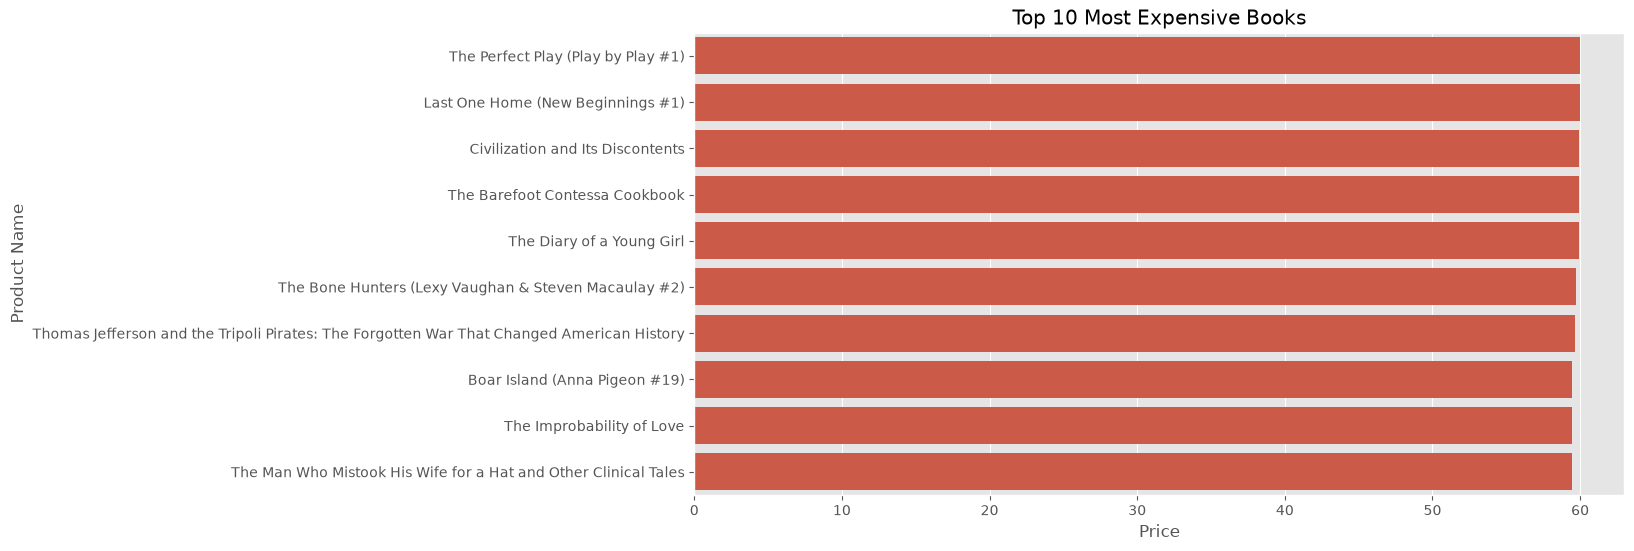

In [21]:
top10 = df.nlargest(10, "Price")

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Price",
    y="Product Name"
)

plt.title("Top 10 Most Expensive Books")

plt.show()

In [23]:
numeric = df.select_dtypes(include="number")

numeric.corr()

,Price
Price,1.0


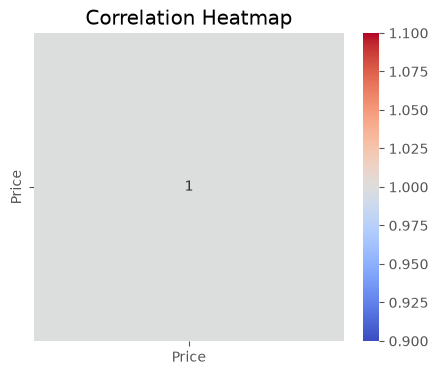

In [24]:
plt.figure(figsize=(5,4))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [25]:
df.to_csv("../data/raw/cleaned_books.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [28]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Ishita@1534",
    database="book_price_intelligence"
)

cursor = conn.cursor()

print("Connected Successfully!")

Connected Successfully!


In [29]:
for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO books
        (product_name, price, rating, availability, product_url)
        VALUES (%s, %s, %s, %s, %s)
    """, (
        row["Product Name"],
        row["Price"],
        row["Rating"],
        row["Availability"],
        row["Product URL"]
    ))

conn.commit()

print("Data uploaded successfully!")

Data uploaded successfully!
